In [14]:
import pandas as pd

# Replace with your actual dataset path
file_path = '/kaggle/input/.csv'

# Load the CSV
df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [16]:
# Define features and target
X = df.drop(["HeartDisease"], axis=1)
y = df["HeartDisease"]

# Check the shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (918, 11)
Target shape: (918,)


In [17]:
# Check missing values
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

# Sort by missing percentage (highest first)
missing_values = missing_values.sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_values)

,Missing Values,Missing Percentage
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0


In [18]:
(df == "?").sum() / len(df) * 100

Age               0.0
Sex               0.0
ChestPainType     0.0
RestingBP         0.0
Cholesterol       0.0
FastingBS         0.0
RestingECG        0.0
MaxHR             0.0
ExerciseAngina    0.0
Oldpeak           0.0
ST_Slope          0.0
HeartDisease      0.0
dtype: float64

In [19]:
# Cholesterol and RestingBP cannot be 0, so zeros are hidden missing values
print("Cholesterol zeros:", (df["Cholesterol"] == 0).sum())
print("RestingBP zeros:", (df["RestingBP"] == 0).sum())

Cholesterol zeros: 172
RestingBP zeros: 1


In [20]:
import numpy as np

# Convert "?" and impossible zeros to NaN
df = df.replace("?", pd.NA)
df[["Cholesterol", "RestingBP"]] = df[["Cholesterol", "RestingBP"]].replace(0, np.nan)

# Calculate missing-value percentage for each column
missing_percentage = df.isnull().mean() * 100

# Drop columns with more than 20% missing values
columns_to_drop = missing_percentage[missing_percentage > 20].index

df = df.drop(columns=columns_to_drop)

# Impute remaining missing values
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        # Numerical columns -> median
        df[column] = df[column].fillna(df[column].median())
    else:
        # Categorical columns -> mode
        df[column] = df[column].fillna(df[column].mode()[0])

# Check remaining missing values
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [21]:
from sklearn.preprocessing import LabelEncoder

# Find all categorical/object columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

# Create a LabelEncoder
le = LabelEncoder()

# Apply label encoding to each categorical column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Check the result
print(df.head())
print(df.dtypes)

   Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0   40    1              1      140.0        289.0          0           1   
1   49    0              2      160.0        180.0          0           1   
2   37    1              1      130.0        283.0          0           2   
3   48    0              0      138.0        214.0          0           1   
4   54    1              2      150.0        195.0          0           1   

   MaxHR  ExerciseAngina  Oldpeak  ST_Slope  HeartDisease  
0    172               0      0.0         2             0  
1    156               0      1.0         1             1  
2     98               0      0.0         2             0  
3    108               1      1.5         1             1  
4    122               0      0.0         2             0  
Age                 int64
Sex                 int64
ChestPainType       int64
RestingBP         float64
Cholesterol       float64
FastingBS           int64
RestingECG          i

In [22]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = df.drop(["HeartDisease"], axis=1)
y = df['HeartDisease']

# Train-test split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (734, 11)
X_test: (184, 11)
y_train: (734,)
y_test: (184,)


In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Naive Bayes model
nb_model = GaussianNB()
# Train the model using the training data
nb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = nb_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.875


In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Scaling methods to compare
scalers = {
    "Standard Scaling": StandardScaler(),
    "Min-Max Scaling": MinMaxScaler(),
    "Robust Scaling": RobustScaler(),
    "Without Scaling": "passthrough"
}

# Models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [25]:
# Train every model with every scaling method and store test accuracy
results = pd.DataFrame(index=models.keys(), columns=scalers.keys(), dtype=float)

for scaler_name, scaler in scalers.items():
    for model_name, model in models.items():
        # Scaler is inside the pipeline, so it is fitted on training data only
        pipe = Pipeline([("scaler", scaler), ("model", clone(model))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        results.loc[model_name, scaler_name] = accuracy_score(y_test, y_pred)

display(results.round(4))

,Standard Scaling,Min-Max Scaling,Robust Scaling,Without Scaling
Logistic Regression,0.8478,0.8533,0.8478,0.8424
KNN,0.8641,0.8533,0.8587,0.6739
Naive Bayes,0.8750,0.8750,0.8750,0.8750
Random Forest,0.8587,0.8587,0.8696,0.8696


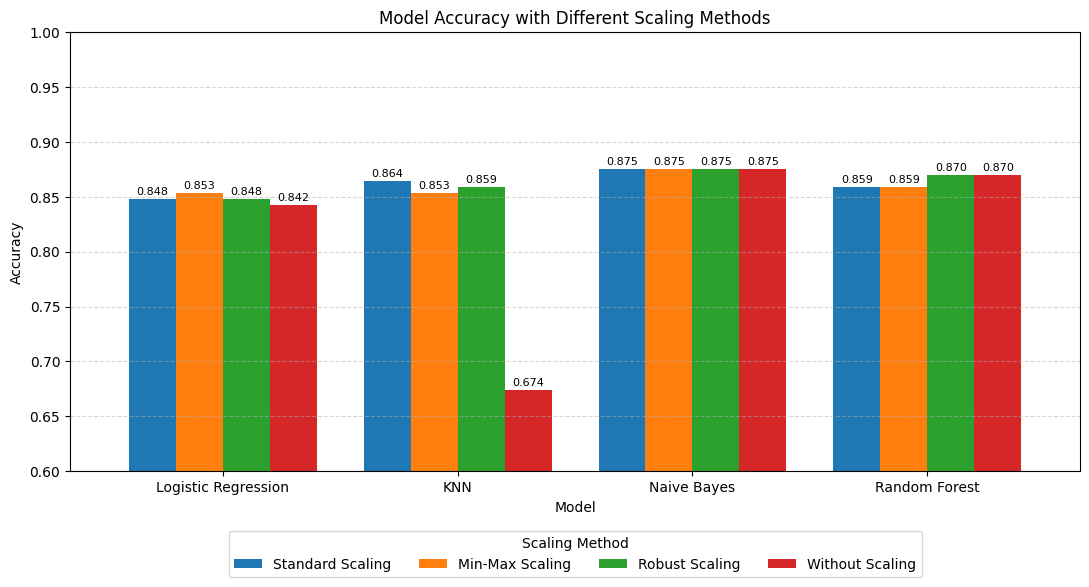

In [26]:
import matplotlib.pyplot as plt

# Grouped bar chart: models on x-axis, one bar per scaling method
ax = results.plot(kind="bar", figsize=(11, 6), width=0.8)

plt.title("Model Accuracy with Different Scaling Methods")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.6, 1.0)
plt.xticks(rotation=0)
plt.legend(title="Scaling Method", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Show accuracy value on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()